Based on a notebook written by [Justin Johnson](https://web.eecs.umich.edu/~justincj/).

Based on Sept 2023, Alekh; Sept 2025, Sixuan; Sept 2026, Peisen

# **CPSY1291 Fall26**
## **Recitation 1**


## **Introduction to Numpy and Linear Algebra**

### This section will briefly introduce you to the basics of linear algebra - focusing on geometric intuition.

Linear algebra
We will roughly follow Prof Simoncelli's notes, working through it in this and subsequent recitations: https://www.cns.nyu.edu/~eero/NOTES/geomLinAlg.pdf

We will use the numpy library for linear algebra in python. Numpy is the core library for scientific computing in Python. It provides a high-performance multidimensional array object, and tools for working with these arrays. If you are already familiar with MATLAB, you might find [this tutorial](https://numpy.org/doc/stable/user/numpy-for-matlab-users.html) useful to get started with numpy.

To use numpy, we first need to import the `numpy` package:

In [ ]:
import numpy as np

In [ ]:
# @title

# helper function to plot vectors
import matplotlib.pyplot as plt


def plot_vector(vectors):
  """
  Plot vectors in a 2D space.

  Params
  ----------
  vectors: list or array-like
    A list or array of 2D vectors to be plotted
  """
  vectors = np.array(vectors)
  if vectors.ndim==1:
    vectors = vectors[np.newaxis, :]
  vecs = np.stack(vectors)
  origin = np.zeros((2, vecs.shape[0])) # origin point
  plt.figure()
  plt.quiver(*origin, vecs[:,0], vecs[:,1], color=['r','b','g','c','m',
                                                   'y','k','w'], angles='xy', scale_units='xy', scale=1)
  plt.axis('square')
  plt.axhline(0, color='black', linewidth=.5)
  plt.axvline(0, color='black', linewidth=.5)
  plt.xlim(-4, 4)
  plt.ylim(-4, 4)
  plt.grid()

A numpy array is a grid of values of the same type. It is indexed by a tuple of integers. The shape of an array gives the size of the array along each dimension.

We can initialize numpy arrays from nested Python lists, and access elements using square brackets:

In [ ]:
a = np.array([1, 2, 3]) # Convert the python list of three numbers into a numpy array
print(type(a), a.dtype) #Display the type and "datatype".
a[0] = 5                # Change an element
print(a)                # Display the entire array

Numeric operations have different meanings for python list and numpy arrray. Numpy offers options to apply the same operation to all elements in an array simultaneously. Refer to Arithmetic, matrix multiplication, and comparison operations section in [this page](https://numpy.org/doc/stable/reference/arrays.ndarray.html#arithmetic-and-comparison-operations).

In [ ]:
p_list = [1, 2, 3]
n_array = np.array(p_list)
print(p_list*2) # This will repeat the list
print(n_array*2) # This will multiply each element in the array by 2


### **Vectors in numpy**

A vector is an ordered collection of numbers, known as the components of the vector:

\begin{align}
  \vec{v} = \begin{bmatrix}
           v_{1} \\
           v_{2} \\
           \vdots \\
           v_{N}
         \end{bmatrix}
  \\
  \\
  \vec{v_1} = \begin{bmatrix}
           1 \\
           2 \\
         \end{bmatrix} \\
         \\
    \vec{v_2} = \begin{bmatrix}
           -1 \\
           3 \\
         \end{bmatrix}
\end{align}


**Norm** of a vector:
 $$\lVert \vec{v} \rVert = \sqrt{v^2_1 + v^2_2 + v^2_3 + .... +v^2_N } $$

* This gives the magnitude of the vector. In two dimensions, it is easy to see that this is the Pythagorean theorem.

* A zero vector has a norm of 0. Can you try coming up with one?

* A unit vector has a norm of 1. In two dimensions, they are all of the form:

  \begin{align}
  \vec{v} = \begin{bmatrix}
          cos(\theta) \\
          sin(\theta) \\
        \end{bmatrix} \\
        \\
  \end{align}
  Can you see why they would have a norm of 1?





In [ ]:
v1 = np.array([1, 2])
plot_vector(v1)


v2 = np.array([-1, 3])
plot_vector([v1, v2])


### **Vector operations**


**Scalar multiplication**

\begin{align}
  \vec{v} = \begin{bmatrix}
           v_{1} \\
           v_{2} \\
           \vdots \\
           v_{N}
         \end{bmatrix}
  \\
  \\
  \text{For a scalar  } a :  \\
  a ⋅ \vec{v} = \begin{bmatrix}
           a v_{1} \\
           a v_{2} \\
           \vdots \\
           a v_{N}
         \end{bmatrix}
  \\
\end{align}

In [ ]:
v1 = np.array([1, 2])
print(1.5*v1)
plot_vector([v1, 1.5 * v1])



**Vector addition**

\begin{align}
    \vec{v_1} = \begin{bmatrix}
           1 \\
           2 \\
         \end{bmatrix} \\
         \\
    \vec{v_2} = \begin{bmatrix}
           -2 \\
           1 \\
         \end{bmatrix}
    \\
    \\
    \vec{v_1} + \vec{v_2} = \begin{bmatrix}
        -1 \\
        3 \\
      \end{bmatrix}
\end{align}


In [ ]:
v1 = np.array([1, 2])
v2 = np.array([-2, 1])
print(v1 + v2)
plot_vector([v1, v2, v1 + v2])


### **Matrices**

Matrices are rectangular array of numbers. We can store matrices as 2D arrays in numpy.

\begin{align}
  M = \begin{bmatrix}
           m_{11} & m_{12} & m_{13} & ... & m_{1m} \\
           m_{21} & m_{22} & m_{23} & ... & m_{2m}\\
           \vdots & \vdots & \vdots & \vdots & \vdots\\
           m_{n1} & m_{n2} & m_{n3} & ... & m_{nm}
         \end{bmatrix}
  \text{is a } n \times m \text{ matrix} \\
\text{}
\end{align}

For example,
\begin{align}
  M = \begin{bmatrix}
           1 & 2 & 1 \\
           3 & 4 & 7 \\
           2 & 6 & 3 \\
           5 & 8 & 2 \\
         \end{bmatrix}
\text{is a } 4 \times 3 \text{ matrix} \\
\end{align}

In [ ]:
b = np.array([[1,2,3],[4,5,6]])   # Create a matrix
print(b)
print(b.shape)

In [ ]:
print(b.shape)
print(b[0, 0], b[0, 1], b[1, 0])



Rule for matrix - vector is as illustrated here:


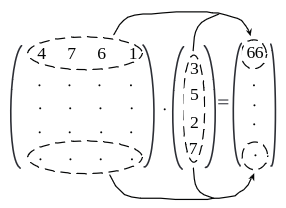


**Now consider this set of linear equations:**
\begin{align}
a_{11}v_1 + a_{12}v_2 +  a_{13} v_3 = b_1 \\
a_{21}v_1 + a_{22}v_2 +  a_{23} v_3 = b_2 \\
a_{31}v_1 + a_{32}v_2 +  a_{33} v_3 = b_3 \\
\\
\end{align}

Usin the above rules for matrix - vector product, these equations can be written as:

\begin{align}
  \begin{bmatrix}
           b_{1}  \\
           b_{2}  \\
           b_{3}  
  \end{bmatrix} = \begin{bmatrix}
           a_{11} & a_{12} & a_{13}  \\
           a_{21} & a_{22} & a_{23}  \\
           a_{31} & a_{32} & a_{33}
        \end{bmatrix}  \begin{bmatrix}
           v_{1}   \\
           v_{2}   \\
           v_{3}
         \end{bmatrix}
\end{align}

**Another way to think about matrix:**

We can consider a matrix as a set of column vectors that represents a linear transformation. The output of a matrix vector multiplication is a linear combination of the columns in the matrix.

In [ ]:
A = np.array([[1,2,3],[4,5,6],[7,8,9]])
v = np.array([[1],[2],[3]])
print("A:", A)
print("\nv:", v)

print("\nAv:", A @ v) # same as np.matmul(A, v)

Numpy also provides many functions to create arrays:

In [ ]:
a = np.zeros((2,2))  # Create an array of all zeros
print(a)

In [ ]:
b = np.ones((1,2))   # Create an array of all ones
print(b)

In [ ]:
d = np.eye(2)        # Create a 2x2 identity matrix
print(d)

In [ ]:
e = np.random.random((2,2)) # Create an array filled with random values
print(e)

### **Array indexing**

Numpy offers several ways to index into arrays.

Slicing: Similar to Python lists, numpy arrays can be sliced. Since arrays may be multidimensional, you must specify a slice for each dimension of the array:

In [2]:
import numpy as np

# Create the following rank 2 array with shape (3, 4)
# [[ 1  2  3  4]
#  [ 5  6  7  8]
#  [ 9 10 11 12]]
a = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12]])

print(a[0]) # First row
print(a[:, 1]) # First column
print(a[:2]) # First 2 rows
print(a[::2]) # Every other rows
print(a[-1]) # last row



[1 2 3 4]
[ 2  6 10]
[[1 2 3 4]
 [5 6 7 8]]
[[ 1  2  3  4]
 [ 9 10 11 12]]
[ 9 10 11 12]


A slice of an array is **a view into the same data**, so modifying it will modify the original array. Check the documentation for other operations as well to prevent accidentally modifying the data.

In [3]:
print(a[0, 1])
b = a[:, 1:3] # b is a view of a, not a copy
b[0, 0] = 77    # b[0, 0] is the same piece of data as a[0, 1]
print(a[0, 1])

2
77


Boolean array indexing: Boolean array indexing lets you pick out arbitrary elements of an array. Frequently this type of indexing is used to select the elements of an array that satisfy some condition. Here is an example:

In [ ]:
a = np.array([[1,2], [3, 4], [5, 6]])

bool_idx = (a > 2)  # Find the elements of a that are bigger than 2;
                    # this returns a numpy array of Booleans of the same
                    # shape as a, where each slot of bool_idx tells
                    # whether that element of a is > 2.

print(bool_idx)

In [ ]:
# We use boolean array indexing to construct a rank 1 array
# consisting of the elements of a corresponding to the True values
# of bool_idx
print(a[bool_idx])

# We can do all of the above in a single concise statement:
print(a[a > 2])

### **Numpy array math operation**

Basic mathematical functions operate elementwise on arrays, and are available both as operator overloads and as functions in the numpy module:

In [ ]:
x = np.array([[1,2],[3,4]], dtype=np.float64)
y = np.array([[5,6],[7,8]], dtype=np.float64)

# Elementwise sum; both produce the array
print(x + y)
print(np.add(x, y))

In [ ]:
# Elementwise difference; both produce the array
print(x - y)
print(np.subtract(x, y))

In [ ]:
# Elementwise product; both produce the array
print(x * y)
print(np.multiply(x, y))

In [ ]:
# Elementwise division; both produce the array
# [[ 0.2         0.33333333]
#  [ 0.42857143  0.5       ]]
print(x / y)
print(np.divide(x, y))

In [ ]:
# Elementwise square; both produce the array
# [[ 1.  4.]
#  [ 9. 16.]]
print(x**2)
print(np.square(x))

In [ ]:
# Elementwise square root; produces the array
# [[ 1.          1.41421356]
#  [ 1.73205081  2.        ]]
print(np.sqrt(x))

Numpy provides many useful functions for performing computations on arrays; one of the most useful is `sum`. The `axis` parameter specifies the dimension the function acts on (the dimension that will disappear after the operation). Specify 1 dimension with an integer or specify multiple dimensions with a tuple.

In [ ]:
x = np.array([[1,2],[3,4]])

print(np.sum(x))  # Compute sum of all elements; prints "10"
print(np.sum(x, axis=0))  # Compute sum of each column; prints "[4 6]"
print(np.sum(x, axis=1))  # Compute sum of each row; prints "[3 7]"

Other useful functions are `max`, `min`, `mean`, `var`, and `std`.


In [ ]:
x = np.array([[1,2],[3,4]])
print(np.max(x, axis=0))  # Compute max of each column; prints "[3 4]"
print(np.min(x, axis=1))  # Compute min of each row; prints "[1 3]"
print(np.mean(x))    # Compute mean of all elements; prints "2.5"
print(np.var(x, axis=(0, 1))) # Compute variance of all elements; prints "1.25"
print(round(np.std(x), 2)) # Compute standard deviation of all elements; prints "1.12"


You can find the full list of mathematical functions provided by numpy in the [documentation](http://docs.scipy.org/doc/numpy/reference/routines.math.html).

Apart from computing mathematical functions using arrays, we frequently need to reshape or otherwise manipulate data in arrays. The simplest example of this type of operation is transposing a matrix; to transpose a matrix, simply use the T attribute of an array object:

In [ ]:
print(f"Matrix \n {x} \n with shape {x.shape}")
print(f"Transpose \n {x.T} \n with shape {x.T.shape}")

Reshape a matrix:

In [ ]:
a = np.random.random([3,4]) # Create a 3x4 array of random numbers between 0 and 1
print(a.shape)

a = a.reshape(2,6) # Reshape a to 2x6 array
print(a.shape)

#### Broadcasting

Unlike matrix operations in linear algebra, matrix operations do not require equal shapes. Numpy will try to expand a lower dimensional array to perform operation on a larger array. The simplest example is adding an integer to all elements in a vector:

In [ ]:
# A scalar is added to every element.
a = np.array([1, 2, 3])
print(a + 10)  # [11, 12, 13]

b = np.array([2,3,4])
# A 1D array is added to each row.
X = np.array([[1, 2, 3],
              [4, 5, 6]])
print(X + b)

## **Matplotlib**

Matplotlib is a plotting library. This section gives a brief introduction to the `matplotlib.pyplot` module, which provides a plotting system similar to that of MATLAB.

In [ ]:
import matplotlib.pyplot as plt
plt.ioff()
import numpy as np

### Plotting

The most important function in `matplotlib` is plot, which allows you to plot 2D data. Here is a simple example:

In [ ]:
# Compute the x and y coordinates for points on a sine curve
x = np.arange(0, 3 * np.pi, 0.1)
y = np.sin(x)
print(x.shape)
print(y.shape)

In [ ]:

# Plot the points using matplotlib
plt.figure(1)
plt.plot(x, y) # Plot the sine curve
plt.xlabel("x axis") # Label the x-axis
plt.show()


With just a little bit of extra work we can easily plot multiple lines at once, and add a title, legend, and axis labels:

In [ ]:
y_sin = np.sin(x)
y_cos = np.cos(x)

# Plot the points using matplotlib
plt.figure(2)
plt.plot(x, y_sin) # Plot the sine curve
plt.plot(x, y_cos) # Plot the cosine curve
plt.xlabel('x axis label') # Label the x-axis
plt.ylabel('y axis label') # Label the y-axis
plt.title('Sine and Cosine') # Add a title
plt.legend(['Sine', 'Cosine']) # Add a legend
plt.show()

### Subplots

You can plot different things in the same figure using the subplot function. Here is an example:

In [ ]:
# Compute the x and y coordinates for points on sine and cosine curves
x = np.arange(0, 3 * np.pi, 0.1)
y_sin = np.sin(x)
y_cos = np.cos(x)

# Set up a subplot grid that has height 2 and width 1,
# and set the first such subplot as active.
plt.subplot(2, 1, 1)

# Make the first plot
plt.plot(x, y_sin)
plt.title('Sine')

# Set the second subplot as active, and make the second plot.
plt.subplot(2, 1, 2)
plt.plot(x, y_cos)
plt.title('Cosine')

# Show the figure.
plt.show()

In [ ]:
#create a random 2D array
im_array = np.random.randint(0, 255, [10,10])

#create a figure and plot the array using imshow
plt.figure(3)
plt.imshow(im_array)
# plt.imshow(im_array, cmap='gray') # cmap controls the color map
plt.colorbar()
plt.show()


# **scikit-learn**
Many algorithms and models in Scikit-learn have a similar interface -


```
#importing the desired algorithm
from sklearn.algorithm import SomeAlgorithm

#create an instance of the class
my_algo = SomeAlgorithm()

#Provide your data to the algorithm so that it can be transformed
new_data = my_algo.fit_transform(my_data)
```



#### **Example with IRIS Dataset**

Iris contains 150 flowers, four measurements in centimeters, and three species with 50 samples each. The feature columns are sepal length, sepal width, petal length, and petal width. The data is organized in a numpy array with shape `(num_samples, num_features)`. This is the same kind of format as the data used in the assignment.

In [ ]:
import subprocess
import sys
print('upgrading scikit-learn for this runtime (about 30 s) ...')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn>=1.8'],
                check=True)


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.metrics import pairwise_distances
from sklearn.datasets import load_iris
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler

# Load IRIS dataset
iris = load_iris()
X = iris.data
y = iris.target

print("X type:", type(X)) # <class 'numpy.ndarray'>
print("X shape:", X.shape) # feature array (num_samples, num_features)
print("y shape:", y.shape) # label array
print("Features:", iris.feature_names) # Name of the features
print("Species:", iris.target_names) # Name of the species labels
print("First five rows:\n", X[:5])

#### Explore the dataset

In [ ]:
print("First flower:", X[0])

print("Feature means:", X.mean(axis=0))
print("Feature standard deviations:", X.std(axis=0))
print("Number of missing values:", np.sum(np.isnan(X)))

# Number per species and feature means per species
for i, name in enumerate(iris.target_names):
    bool_mask = y == i
    print(name, "count:", np.sum(bool_mask),
          "\nmean feature vector:", X[bool_mask].mean(axis=0))


#### Prepare distance matrix for MDS

MDS expects a distance matrix to project the points into a lower dimensional coordinate system while preserving the original distance relationships.

In [ ]:
# Standardize the data (z-score normalization)
X = (X - X.mean(axis=0)) / X.std(axis=0)
# Compute the pairwise Euclidean distance matrix with all four features
distance_matrix = pairwise_distances(X, metric='euclidean')
# Create sklearn MDS model
mds = MDS(n_components=2, metric_mds=False, metric='precomputed',
          init='random', n_init=4, max_iter=400, random_state=6,
          normalized_stress='auto')
mds_coords = mds.fit_transform(distance_matrix)

#### Visualize the output

In [ ]:
figure, ax = plt.subplots()
for species in sorted(set(y)):
    species_mask = y == species
    ax.scatter(mds_coords[species_mask, 0], mds_coords[species_mask, 1], label=iris.target_names[species])
ax.legend()
ax.set_title("MDS of IRIS dataset")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

### **Suggestions for debugging**

1. Read the documentation of the packages.
2. **Shape**. Print of the shape, confirm that you are operating on the correct dimension.
3. **Type and range**. Examine the data type of the array. Check if the min-max range is reasonable when the plot looks different then what you epxected.
4. Check your pipeline with a simple example.